#**PREDICTING ADR (AVERAGE DAILY RATE) IN HOTELS**

##**STEP 1: DATA EXPLORATION AND SUMMARY STATISTICS**
The ADR distribution which is right-skewed, shows that most room prices fall between RM 150 and RM 400. The mean which is RM 294 is higher than the median of RM 245, showing the presence of high-priced outliers in the data.

Mean: 294.42, Median: 245.28, Skewness: 1.37


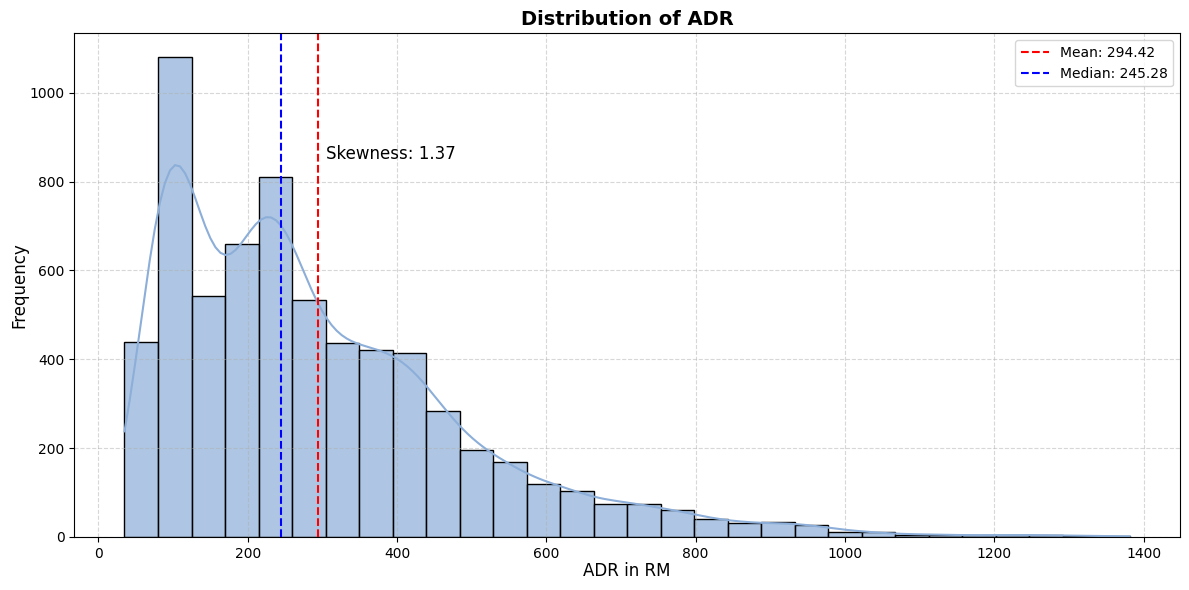

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# Load ADR data and clean missing values
df = pd.read_csv('Hospitality_Wrangling_EDA_Regression.csv')
adr = df['ADR_RM'].dropna()

# Calculate mean, median, and skewness
mean_val = adr.mean()
median_val = adr.median()
skew_val = skew(adr)

# Print summary statistics
print(f"Mean: {mean_val:.2f}, Median: {median_val:.2f}, Skewness: {skew_val:.2f}")

# Plot histogram with KDE and mean/median lines
plt.figure(figsize=(12, 6))
sns.histplot(adr, kde=True, bins=30, color="#8caed8", alpha=0.7)
plt.axvline(mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, color='blue', linestyle='--', label=f"Median: {median_val:.2f}")
plt.text(mean_val + 10, plt.ylim()[1] * 0.75, f"Skewness: {skew_val:.2f}", fontsize=12)

# Show the plot
plt.title("Distribution of ADR", fontsize=14, fontweight='bold', pad=6)
plt.xlabel("ADR in RM", fontsize=12, labelpad=1)
plt.ylabel("Frequency", fontsize=12, labelpad=1)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##**STEP 2: HANDLING DATA ISSUES**
The missing ADR values were filled in using the mean, and duplicate rows were removed. Outlier capping at the 1st and 99th percentiles made the ADR range more realistic without distorting the overall pricing distribution.

 Guest_Nights  Last_Minute_Booking Age_Group
        3.136                    0     18-24
        3.084                    0     18-24
        1.430                    0     35-44
        1.560                    0     18-24
        1.736                    0     35-44


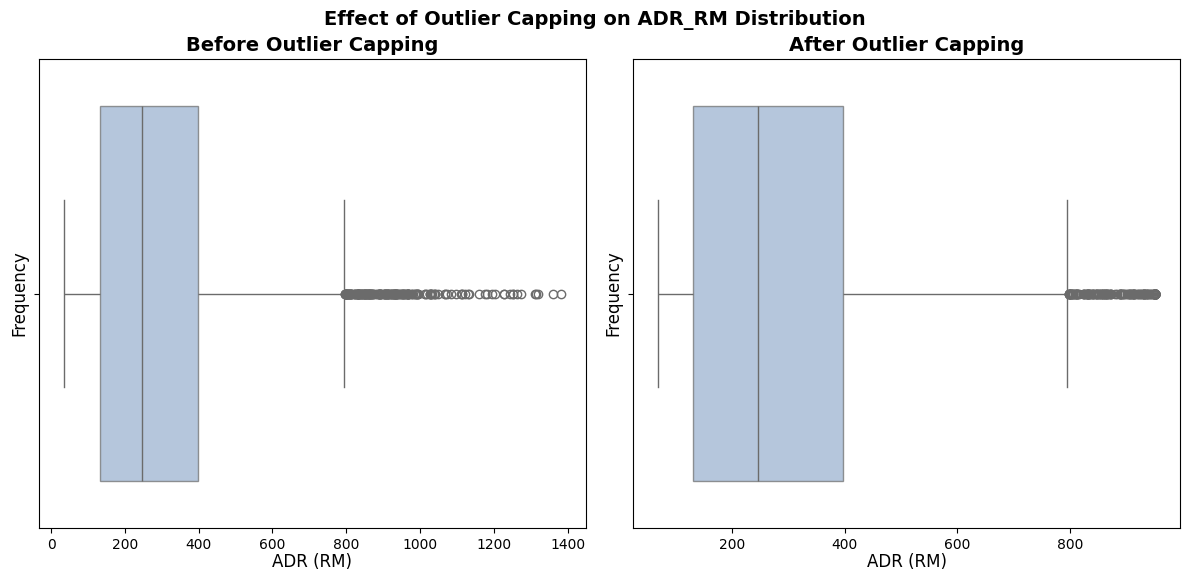

In [ ]:
# Handle missing ADR values using mean
df['ADR_RM'] = df['ADR_RM'].fillna(df['ADR_RM'].mean())

# Capping outliers using 1st and 99th percentiles
lower_cap = df['ADR_RM'].quantile(0.01)
upper_cap = df['ADR_RM'].quantile(0.99)
df['ADR_RM_Capped'] = df['ADR_RM'].clip(lower_cap, upper_cap)

# Create Guest_Nights
df['Guest_Nights'] = df['Nights_Stayed'] * df['Occupancy_Rate_Property']

# Create Last_Minute_Booking
df['Last_Minute_Booking'] = (df['Lead_Time_Days'] <= 7).astype(int)

# Create Age Group
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels, right=False)

# Display the first few rows without data types showing
print(df[['Guest_Nights', 'Last_Minute_Booking', 'Age_Group']].head().to_string(index=False))

# Boxplot visualization before and after outlier capping
plt.figure(figsize=(12, 6))
common_min = df['ADR_RM'].min()
common_max = df['ADR_RM'].max()

# Before outlier capping
plt.subplot(1, 2, 1)
sns.boxplot(x=df['ADR_RM'], color="#8caed8", boxprops=dict(alpha=0.7))
plt.title("Before Outlier Capping", fontsize=14, fontweight='bold', pad=6)
plt.xlabel("ADR (RM)", fontsize=12, labelpad=1)
plt.ylabel("Frequency", fontsize=12, labelpad=1)

# After outlier capping
plt.subplot(1, 2, 2)
sns.boxplot(x=df['ADR_RM_Capped'], color="#8caed8", boxprops=dict(alpha=0.7))
plt.title("After Outlier Capping", fontsize=14, fontweight='bold', pad=6)
plt.xlabel("ADR (RM)", fontsize=12, labelpad=1)
plt.ylabel("Frequency", fontsize=12, labelpad=1)

# Show boxplot with outlier capping effect
plt.suptitle("Effect of Outlier Capping on ADR_RM Distribution", fontsize=14, fontweight='bold', y=0.96)
plt.tight_layout()
plt.show()

##**STEP 3: FEATURE ENGINEERING AND TRANSFORMATION**
New features were created to enhance prediction. Guest-Nights (hotel stay volume), a binary feature for last-minute bookings (≤ 7 days), and customer age groups to capture different traveler segments were added.

In [ ]:
# Feature 1: Estimate of guest-nights based on stay volume and occupancy rate
df['Guest_Nights'] = df['Nights_Stayed'] * df['Occupancy_Rate_Property']

# Feature 2: Binary feature for last-minute booking (≤ 7 days)
df['Last_Minute_Booking'] = (df['Lead_Time_Days'] <= 7).astype(int)

# Feature 3: Age groups to segment customers by age
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–24', '25–34', '35–44', '45–54', '55–64', '65+']

df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels, right=False)

# Show a preview of selected features
print(df[['Guest_Nights', 'Last_Minute_Booking', 'Age_Group']].head())

   Guest_Nights  Last_Minute_Booking Age_Group
0         3.136                    0     18–24
1         3.084                    0     18–24
2         1.430                    0     35–44
3         1.560                    0     18–24
4         1.736                    0     35–44


##**STEP 4: EXPLORATORY DATA ANALYSIS (EDA) ON CORRELATIONS**
There is a strong positive correlation between ADR and the Competitor Average Rate, Star Rating, Total Spend, and Review Score. This suggests that higher-priced and better-rated hotels are likely to charge a higher ADR.

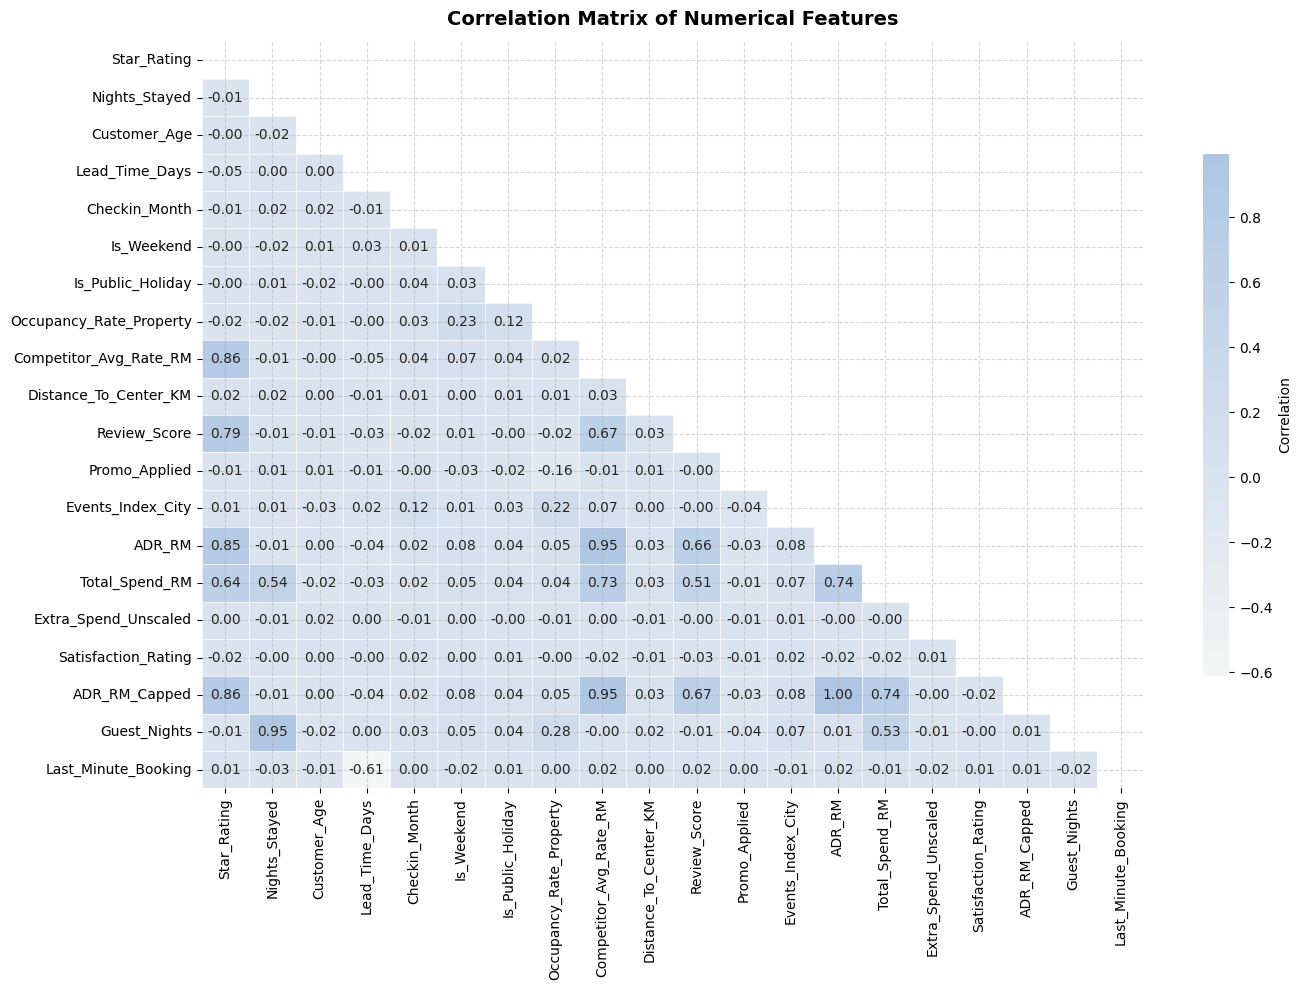


Correlation with ADR_RM:
ADR_RM                     1.000000
ADR_RM_Capped              0.996446
Competitor_Avg_Rate_RM     0.950410
Star_Rating                0.847474
Total_Spend_RM             0.741080
Review_Score               0.664896
Is_Weekend                 0.080277
Events_Index_City          0.077934
Occupancy_Rate_Property    0.054347
Is_Public_Holiday          0.039838
Distance_To_Center_KM      0.028982
Checkin_Month              0.022475
Last_Minute_Booking        0.015018
Guest_Nights               0.006876
Customer_Age               0.001841
Extra_Spend_Unscaled      -0.000553
Nights_Stayed             -0.013321
Satisfaction_Rating       -0.022781
Promo_Applied             -0.029533
Lead_Time_Days            -0.042668

Strong Correlations with ADR_RM (|corr| > 0.5):
ADR_RM                    1.000000
ADR_RM_Capped             0.996446
Competitor_Avg_Rate_RM    0.950410
Star_Rating               0.847474
Total_Spend_RM            0.741080
Review_Score              0.66

In [ ]:
# Select numeric columns and remove 'Booking_ID'
numeric_df = df.select_dtypes(include=['float64', 'int64'])
numeric_df = numeric_df.drop(columns=['Booking_ID'], errors='ignore')

# Compute correlation matrix and mask upper triangle
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
plt.figure(figsize=(14, 10))
cmap = sns.light_palette("#8caed8", as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap=cmap,
            linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.7, 'label': 'Correlation'},
            alpha=0.7, annot_kws={"size": 10, 'ha': 'center', 'va': 'center'})
plt.title("Correlation Matrix of Numerical Features", fontweight="bold", fontsize=14, pad=12)
plt.xticks(rotation=90, ha="center", fontsize=10)
plt.yticks(rotation=0, ha="right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print correlation with ADR_RM (sorted) and highlight strong correlations (>0.5)
if 'ADR_RM' in numeric_df.columns:
    print("\nCorrelation with ADR_RM:")
    print(corr_matrix['ADR_RM'].sort_values(ascending=False).to_string(index=True))
    strong_corr = corr_matrix['ADR_RM'].abs().sort_values(ascending=False)
    print("\nStrong Correlations with ADR_RM (|corr| > 0.5):")
    print(strong_corr[strong_corr > 0.5].to_string())

##**STEP 5: MODEL SELECTION**
a) Linear Regression - Simple and interpretable model that provides a baseline for understanding linear relationships between hotel features and ADR.         
b) Random Forest Regressor - Captures non-linear interactions and reduces overfitting through bagging and ensemble learning.                        
c) Gradient Boosting Regressor - Improves prediction accuracy by sequentially
correcting errors, making it highly effective for complex pricing patterns, although it can be more computationally expensive.

##**STEP 6: MODEL IMPLEMENTATION**
Gradient Boosting gave the best performance with the lowest RMSE and MAE and the highest R² score, so it predicts ADR most accurately among the models.

In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Drop rows with missing values
df_simple = df.dropna()

# Define targets and features
y = df_simple['ADR_RM']
X = df_simple.drop(
    columns=['ADR_RM', 'ADR_RM_Capped', 'Booking_ID', 'Checkin_Date'],
    errors='ignore')

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {"Linear Regression": LinearRegression(),
          "Random Forest": RandomForestRegressor(random_state=42),
          "Gradient Boosting": GradientBoostingRegressor(random_state=42)}

# Create an empty list to store results
results = []

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append([name, rmse, mae, r2])

# Show the model performance
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R² Score"])
print("\nModel Performance Comparison:")
print(results_df.sort_values(by="RMSE"))


Model Performance Comparison:
               Model       RMSE        MAE  R² Score
2  Gradient Boosting  36.052249  20.842535  0.969472
1      Random Forest  36.081164  21.502309  0.969423
0  Linear Regression  44.223920  27.846233  0.954065


##**STEP 7: MODEL EVALUATION AND COMPARISON**
The evaluation metrics confirm that Gradient Boosting provides the most accurate ADR predictions, outperforming the other models in both error reduction and R² accuracy.

In [ ]:
# Import a necessary library
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Make predictions again
lr_pred = models["Linear Regression"].predict(X_test)
rf_pred = models["Random Forest"].predict(X_test)
gb_pred = models["Gradient Boosting"].predict(X_test)

# Evaluate function
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    return mse, rmse, r2, mae

# Run evaluations
lr_mse, lr_rmse, lr_r2, lr_mae = evaluate_model(y_test, lr_pred)
rf_mse, rf_rmse, rf_r2, rf_mae = evaluate_model(y_test, rf_pred)
gb_mse, gb_rmse, gb_r2, gb_mae = evaluate_model(y_test, gb_pred)

# Print results clearly
print(f"Linear Regression: MSE={lr_mse:.2f}, RMSE={lr_rmse:.2f}, R²={lr_r2:.2f}, MAE={lr_mae:.2f}")
print(f"Random Forest: MSE={rf_mse:.2f}, RMSE={rf_rmse:.2f}, R²={rf_r2:.2f}, MAE={rf_mae:.2f}")
print(f"Gradient Boosting: MSE={gb_mse:.2f}, RMSE={gb_rmse:.2f}, R²={gb_r2:.2f}, MAE={gb_mae:.2f}")

Linear Regression: MSE=1955.76, RMSE=44.22, R²=0.95, MAE=27.85
Random Forest: MSE=1301.85, RMSE=36.08, R²=0.97, MAE=21.50
Gradient Boosting: MSE=1299.76, RMSE=36.05, R²=0.97, MAE=20.84


##**STEP 8: MODEL OPTIMISATION AND PARAMETER TUNING**
Hyperparameter tuning on the Gradient Boosting model improved its performance by reducing prediction errors and slightly increasing the R² score, making it more accurate for ADR forecasting.

In [ ]:
# Import necessary libraries
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# Parameter tuning grid
param_grid = {"n_estimators": [50, 100],
              "learning_rate": [0.05, 0.1],
              "max_depth": [2, 3]}

# GridSearch on Gradient Boosting
grid_search = GridSearchCV(GradientBoostingRegressor(random_state=42),
                           param_grid,
                           cv=3,
                           scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

# Best tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

# Evaluate improvement
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_r2 = r2_score(y_test, y_pred_tuned)
print(f"Tuned Gradient Boosting -> RMSE: {tuned_rmse:.2f}, MAE: {tuned_mae:.2f}, R²: {tuned_r2:.2f}")

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Tuned Gradient Boosting -> RMSE: 36.05, MAE: 20.84, R²: 0.97
